# MediTrack Nigeria — Hospital Analytics Case Study
## Solving 5 Clinical and Operational Business Problems with Data

**Organisation:** MediTrack Nigeria (multi-department hospital — fictional)
**Period:** July 2023 – June 2024
**Dataset:** 25,000 patients | 62,135 appointments | 43,893 billing records

---

### Business Problems We Are Solving
1. Why is monthly revenue fluctuating despite growing patient numbers?
2. Which departments have the worst no-show rates and why?
3. Which patients are most at risk of dropping out of care?
4. Which registration channel brings the most loyal patients?
5. How do we improve patient satisfaction and reduce wait times?

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'#f8fafb','axes.facecolor':'#f8fafb',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.spines.left':False,'axes.spines.bottom':False,
    'axes.grid':True,'grid.color':'#e2e8f0','grid.linewidth':0.8,
    'font.family':'DejaVu Sans','axes.labelcolor':'#475569',
    'xtick.color':'#94a3b8','ytick.color':'#94a3b8','text.color':'#1e293b',
})

TEAL   = '#0d9488'; BLUE = '#1d4ed8'; RED  = '#dc2626'
AMBER  = '#d97706'; GREEN= '#16a34a'; PURPLE='#7c3aed'; GRAY='#94a3b8'
print("Libraries loaded")

Libraries loaded


In [2]:
# Load data — update paths if needed
patients = pd.read_csv('meditrack_patients.csv')
appts    = pd.read_csv('meditrack_appointments.csv')
bills    = pd.read_csv('meditrack_billing.csv')

patients['registration_date'] = pd.to_datetime(patients['registration_date'])
patients['last_visit_date']   = pd.to_datetime(patients['last_visit_date'])
appts['appt_date']            = pd.to_datetime(appts['appt_date'])
bills['bill_date']            = pd.to_datetime(bills['bill_date'])

print(f"Patients:     {len(patients):,}")
print(f"Appointments: {len(appts):,}")
print(f"Billing rows: {len(bills):,}")
print(f"Active patients: {patients['is_active'].sum():,} ({patients['is_active'].mean()*100:.1f}%)")
print(f"Total revenue: ₦{bills['total_collected'].sum():,.0f}")
print(f"Overall no-show rate: {(appts['status']=='No-Show').mean()*100:.1f}%")

Patients:     25,000
Appointments: 62,135
Billing rows: 43,893
Active patients: 6,658 (26.6%)
Total revenue: ₦796,296,700
Overall no-show rate: 19.7%


---
## Problem 1 — Why Is Revenue Fluctuating Despite Growing Patients?

HMO reimbursement was cut from 72% to 55% coverage in January 2024. This reduced what the hospital collects from insured patients even though patient volume kept growing.

In [3]:
monthly = bills.groupby('bill_month').agg(
    revenue         =('total_collected','sum'),
    unique_patients =('patient_id','nunique'),
    bills           =('bill_id','count'),
    avg_bill        =('total_collected','mean')
).reset_index()
monthly['rev_per_patient'] = (monthly['revenue']/monthly['unique_patients']).round(0)
monthly['revenue_M'] = (monthly['revenue']/1e6).round(2)

print("Monthly Revenue Summary:")
print(monthly[['bill_month','revenue_M','unique_patients','avg_bill','rev_per_patient']].to_string(index=False))

Monthly Revenue Summary:
bill_month  revenue_M  unique_patients     avg_bill  rev_per_patient
   2023-07      25.23             1019 18602.581121          24755.0
   2023-08      53.11             2154 18051.189667          24655.0
   2023-09      61.67             2415 18490.554723          25535.0
   2023-10      68.60             2656 18099.551451          25827.0
   2023-11      70.48             2787 17983.924471          25288.0
   2023-12      76.69             2956 18010.192579          25943.0
   2024-01      75.13             2935 18008.053691          25598.0
   2024-02      70.60             2807 17895.766793          25151.0
   2024-03      77.32             2991 18387.372176          25851.0
   2024-04      78.29             3010 18102.335260          26011.0
   2024-05      80.69             3099 18217.927297          26037.0
   2024-06      58.51             2445 18187.193037          23930.0


In [4]:
# HMO reimbursement impact
hmo = bills[bills['payment_type']=='HMO/Insurance'].copy()
hmo['period'] = hmo['bill_date'].apply(
    lambda d: 'Pre-Jan 2024' if d < pd.Timestamp('2024-01-01') else 'Post-Jan 2024')

hmo_comp = hmo.groupby('period').agg(
    bills          =('bill_id','count'),
    avg_gross      =('gross_amount','mean'),
    avg_hmo_pays   =('hmo_payment','mean'),
    avg_collected  =('total_collected','mean'),
    total_collected=('total_collected','sum')
).round(0)
hmo_comp['hmo_coverage_pct'] = (hmo_comp['avg_hmo_pays']/hmo_comp['avg_gross']*100).round(1)
print("HMO Reimbursement: Before vs After January 2024")
print(hmo_comp.to_string())
print()
pre_cov  = hmo_comp.loc['Pre-Jan 2024','hmo_coverage_pct']
post_cov = hmo_comp.loc['Post-Jan 2024','hmo_coverage_pct']
rev_diff = hmo_comp.loc['Pre-Jan 2024','avg_collected'] - hmo_comp.loc['Post-Jan 2024','avg_collected']
print(f"HMO coverage dropped from {pre_cov}% to {post_cov}%")
print(f"Average revenue lost per HMO bill: ₦{abs(rev_diff):,.0f}")
print(f"With {hmo_comp.loc['Post-Jan 2024','bills']:,} post-Jan HMO bills:")
lost = abs(rev_diff) * hmo_comp.loc['Post-Jan 2024','bills']
print(f"Estimated revenue shortfall: ₦{lost:,.0f}")

HMO Reimbursement: Before vs After January 2024
               bills  avg_gross  avg_hmo_pays  avg_collected  total_collected  hmo_coverage_pct
period                                                                                         
Post-Jan 2024   9999    18701.0       10287.0        18701.0      186990800.0              55.0
Pre-Jan 2024    7329    18270.0       13155.0        18270.0      133899600.0              72.0

HMO coverage dropped from 72.0% to 55.0%
Average revenue lost per HMO bill: ₦431
With 9,999 post-Jan HMO bills:
Estimated revenue shortfall: ₦4,309,569


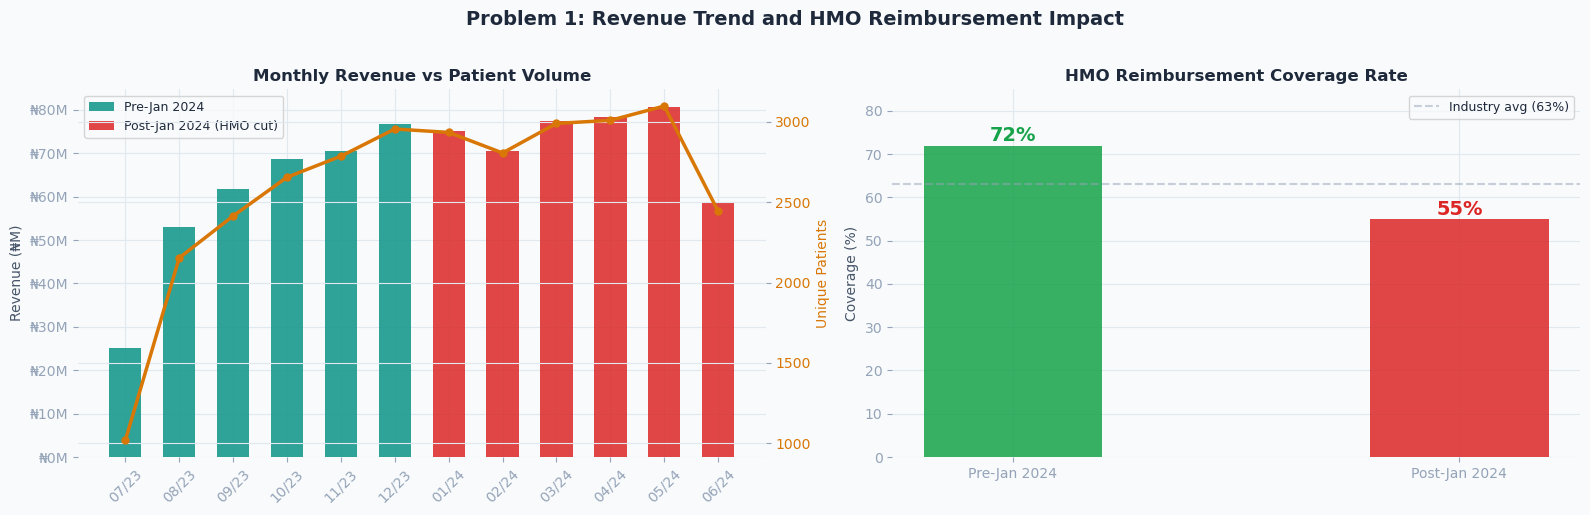

Saved p1_revenue.png


In [5]:
fig, axes = plt.subplots(1,2,figsize=(16,5))
fig.suptitle('Problem 1: Revenue Trend and HMO Reimbursement Impact',
             fontsize=14, fontweight='bold', y=1.02)

months_s = [m[-2:]+'/'+m[2:4] for m in monthly['bill_month']]
bar_colors = [RED if m>='2024-01' else TEAL for m in monthly['bill_month']]
axes[0].bar(months_s, monthly['revenue_M'], color=bar_colors, alpha=0.85, width=0.6, zorder=2)
ax2 = axes[0].twinx()
ax2.plot(months_s, monthly['unique_patients'], color=AMBER, linewidth=2.5,
         marker='o', markersize=5, zorder=3, label='Unique Patients')
ax2.set_ylabel('Unique Patients', color=AMBER)
ax2.tick_params(axis='y', labelcolor=AMBER)
ax2.spines['right'].set_visible(False)
axes[0].set_title('Monthly Revenue vs Patient Volume', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Revenue (₦M)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₦{x:.0f}M'))
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(facecolor=TEAL,alpha=0.85,label='Pre-Jan 2024'),
                          Patch(facecolor=RED,alpha=0.85,label='Post-Jan 2024 (HMO cut)')], loc='upper left', fontsize=9)

# HMO coverage comparison
periods=['Pre-Jan 2024','Post-Jan 2024']
coverage=[72,55]
axes[1].bar(periods, coverage, color=[GREEN,RED], alpha=0.85, width=0.4, zorder=2)
axes[1].set_title('HMO Reimbursement Coverage Rate', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Coverage (%)')
axes[1].set_ylim(0,85)
for i,(v,p) in enumerate(zip(coverage,periods)):
    axes[1].text(i, v+1, f'{v}%', ha='center', fontsize=14, fontweight='bold',
                 color=GREEN if i==0 else RED)
axes[1].axhline(y=63, color=GRAY, linestyle='--', alpha=0.5, label='Industry avg (63%)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('p1_revenue.png', dpi=150, bbox_inches='tight', facecolor='#f8fafb')
plt.show()
print("Saved p1_revenue.png")

---
## Problem 2 — Which Departments Have the Worst No-Show Rates?

Mental Health (44.7%) and Dental (43.4%) have catastrophically high no-show rates. Maternity's no-show rate doubled from 16.1% to 30.1% after January 2024 due to staff shortages causing long wait times.

In [6]:
noshow = appts.groupby('department').agg(
    total       =('appt_id','count'),
    no_shows    =('status', lambda x: (x=='No-Show').sum()),
    completed   =('status', lambda x: (x=='Completed').sum()),
    avg_wait    =('wait_time_min','mean'),
    avg_sat     =('satisfaction','mean')
).round(1).reset_index()
noshow['noshow_rate'] = (noshow['no_shows']/noshow['total']*100).round(1)
noshow = noshow.sort_values('noshow_rate', ascending=False)

print("No-Show Rate by Department:")
print(noshow[['department','total','no_shows','noshow_rate','avg_wait','avg_sat']].to_string(index=False))
print()
mat = appts[appts['department']=='Maternity'].copy()
mat['period'] = mat['appt_date'].apply(
    lambda d: 'Pre-Jan 2024' if d < pd.Timestamp('2024-01-01') else 'Post-Jan 2024')
print("Maternity Department: Before vs After Jan 2024 (Staff Shortage)")
print(mat.groupby('period').agg(
    avg_wait_min=('wait_time_min','mean'),
    noshow_rate =('status',lambda x:(x=='No-Show').mean()*100),
    avg_satisfaction=('satisfaction','mean')
).round(1).to_string())

No-Show Rate by Department:
      department  total  no_shows  noshow_rate  avg_wait  avg_sat
   Mental Health   2262      1010         44.7      37.3      4.1
          Dental   2621      1138         43.4      37.5      4.1
       Maternity  10362      2505         24.2      64.7      3.3
       Emergency   2131       379         17.8      44.5      3.8
      Cardiology   9464      1548         16.4      37.8      4.1
     Paediatrics   6788      1108         16.3      37.6      4.1
   Ophthalmology   3014       489         16.2      37.5      4.1
General Practice  17866      2880         16.1      37.4      4.1
     Dermatology   3315       518         15.6      38.1      4.1
    Orthopaedics   4312       657         15.2      38.1      4.1

Maternity Department: Before vs After Jan 2024 (Staff Shortage)
               avg_wait_min  noshow_rate  avg_satisfaction
period                                                    
Post-Jan 2024          84.3         30.1               2.7
Pre-

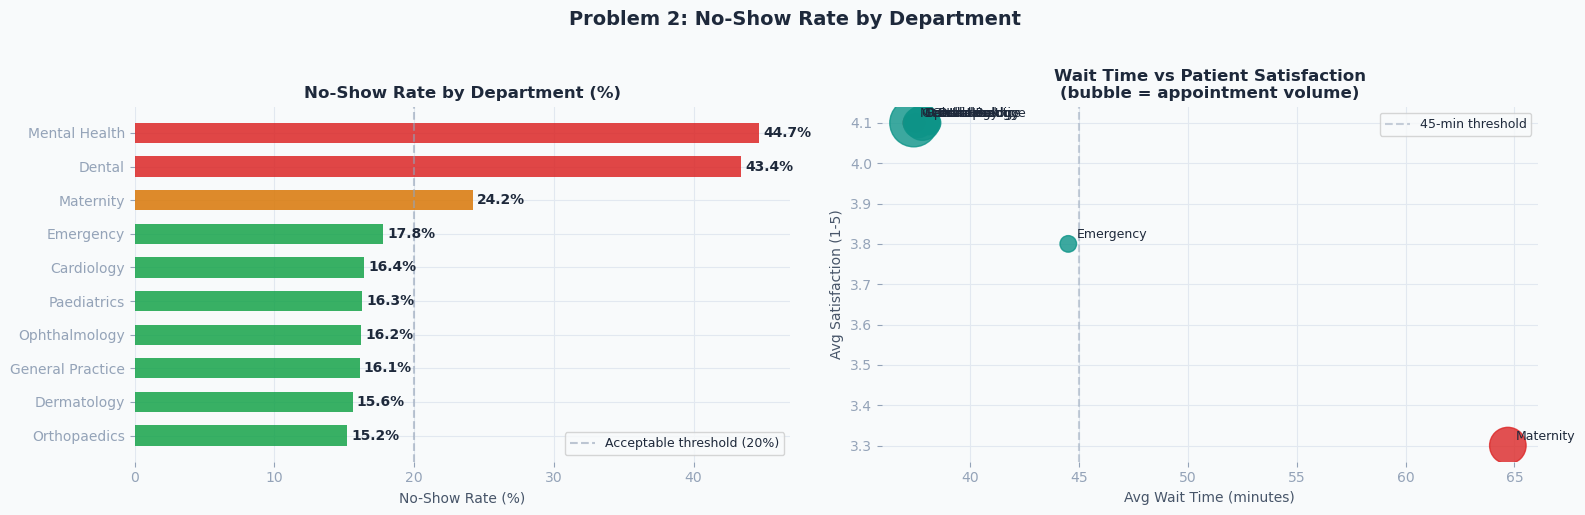

Saved p2_noshow.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Problem 2: No-Show Rate by Department', fontsize=14, fontweight='bold', y=1.02)

ns_sorted = noshow.sort_values('noshow_rate')
bar_c = [RED if v > 30 else AMBER if v > 20 else GREEN for v in ns_sorted['noshow_rate']]
bars = axes[0].barh(ns_sorted['department'], ns_sorted['noshow_rate'],
                    color=bar_c, alpha=0.85, height=0.6, zorder=2)
axes[0].set_title('No-Show Rate by Department (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('No-Show Rate (%)')
axes[0].axvline(x=20, color=GRAY, linestyle='--', alpha=0.6, label='Acceptable threshold (20%)')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, ns_sorted['noshow_rate']):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{val}%', va='center', fontsize=10, fontweight='bold')

# Wait time vs satisfaction
scatter_c = [RED if r in ['Mental Health', 'Dental', 'Maternity'] else TEAL for r in noshow['department']]
axes[1].scatter(noshow['avg_wait'], noshow['avg_sat'], s=noshow['total'] / 15,
                c=scatter_c, alpha=0.8, zorder=3)
for _, row in noshow.iterrows():
    axes[1].annotate(row['department'], (row['avg_wait'], row['avg_sat']),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)
axes[1].set_title('Wait Time vs Patient Satisfaction\n(bubble = appointment volume)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Avg Wait Time (minutes)')
axes[1].set_ylabel('Avg Satisfaction (1-5)')
axes[1].axvline(x=45, color=GRAY, linestyle='--', alpha=0.5, label='45-min threshold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('p2_noshow.png', dpi=150, bbox_inches='tight', facecolor='#f8fafb')
plt.show()
print("Saved p2_noshow.png")

---
## Problem 3 — Which Patients Are Most at Risk of Dropping Out?

Dropout risk is highest among Out-of-Pocket payers (price sensitivity), Social Media and Online Search patients (low commitment), and patients in Mental Health and Dental departments (stigma and cost).

In [11]:
# Dropout risk by payment type
pay_risk = patients.groupby('payment_type').agg(
    patients      =('patient_id','count'),
    active        =('is_active','sum'),
    avg_visits    =('total_visits','mean'),
    avg_risk      =('dropout_risk_score','mean')
).reset_index()
pay_risk['active_rate'] = (pay_risk['active']/pay_risk['patients']*100).round(1)
pay_risk['dropout_rate']= (100 - pay_risk['active_rate']).round(1)
pay_risk = pay_risk.sort_values('dropout_rate',ascending=False)

print("Dropout Rate by Payment Type:")
print(pay_risk[['payment_type','patients','active_rate','dropout_rate','avg_visits','avg_risk']].round(1).to_string(index=False))
print()

# High risk patients
high_risk = patients[patients['dropout_risk_score']>75]
print(f"High dropout risk patients (score > 75): {len(high_risk):,} ({len(high_risk)/len(patients)*100:.1f}%)")
print()
print("High Risk by Department:")
print(high_risk.groupby('primary_dept').agg(
    count=('patient_id','count'),
    avg_risk=('dropout_risk_score','mean')
).sort_values('count',ascending=False).round(1).to_string())

Dropout Rate by Payment Type:
 payment_type  patients  active_rate  dropout_rate  avg_visits  avg_risk
Out-of-Pocket      8730         22.7          77.3         1.2      91.2
         NHIS      4534         25.4          74.6         1.5      81.2
    NGO/Donor      1220         26.9          73.1         1.5      80.5
    Corporate      2448         27.2          72.8         1.8      78.5
HMO/Insurance      8068         31.3          68.7         1.8      76.1

High dropout risk patients (score > 75): 17,892 (71.6%)

High Risk by Department:
                  count  avg_risk
primary_dept                     
General Practice   5327      98.4
Maternity          2437      98.4
Paediatrics        2326      98.4
Cardiology         2049      98.5
Orthopaedics       1407      98.3
Dental             1041      98.3
Dermatology        1031      98.3
Ophthalmology       882      98.5
Mental Health       851      98.6
Emergency           541      98.0


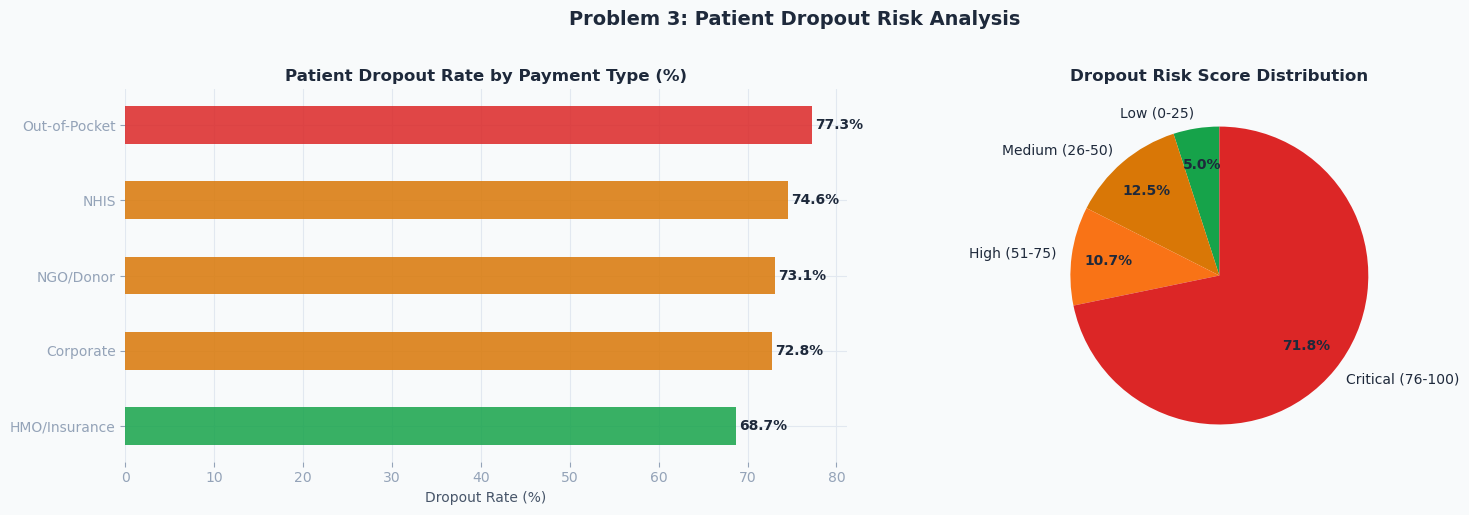

Saved p3_dropout.png


In [13]:
fig, axes = plt.subplots(1,2,figsize=(16,5))
fig.suptitle('Problem 3: Patient Dropout Risk Analysis',fontsize=14,fontweight='bold',y=1.02)

# Dropout by payment type
pay_sorted = pay_risk.sort_values('dropout_rate',ascending=True)
dc = [RED if v>75 else AMBER if v>70 else GREEN for v in pay_sorted['dropout_rate']]
bars = axes[0].barh(pay_sorted['payment_type'], pay_sorted['dropout_rate'],
                    color=dc, alpha=0.85, height=0.5, zorder=2)
axes[0].set_title('Patient Dropout Rate by Payment Type (%)',fontsize=12,fontweight='bold')
axes[0].set_xlabel('Dropout Rate (%)')
for bar,val in zip(bars,pay_sorted['dropout_rate']):
    axes[0].text(val+0.3,bar.get_y()+bar.get_height()/2,
                 f'{val}%',va='center',fontsize=10,fontweight='bold')

# Risk score distribution
risk_counts = pd.cut(patients['dropout_risk_score'],
    bins=[0,25,50,75,100],labels=['Low (0-25)','Medium (26-50)','High (51-75)','Critical (76-100)'])
rc = risk_counts.value_counts().sort_index()
pie_colors = [GREEN,AMBER if True else AMBER,RED]
pie_c = [GREEN, AMBER, '#f97316', RED]
wedges,texts,autotexts = axes[1].pie(rc.values,labels=rc.index,colors=pie_c,
    autopct='%1.1f%%',startangle=90,pctdistance=0.75)
for at in autotexts: at.set_fontsize(10); at.set_fontweight('bold')
axes[1].set_title('Dropout Risk Score Distribution',fontsize=12,fontweight='bold')

plt.tight_layout()
plt.savefig('p3_dropout.png',dpi=150,bbox_inches='tight',facecolor='#f8fafb')
plt.show()
print("Saved p3_dropout.png")

---
## Problem 4 — Which Channel Brings the Most Loyal Patients?

Doctor Referral patients have a 32.3% active rate — nearly 1.5x better than Walk-in or Online Search patients. Insurance Partner patients are second best. Social Media has the lowest retention.

In [14]:
ch_quality = patients.groupby('channel').agg(
    patients   =('patient_id','count'),
    active     =('is_active','sum'),
    avg_visits =('total_visits','mean'),
    avg_risk   =('dropout_risk_score','mean')
).reset_index()
ch_quality['active_rate']  = (ch_quality['active']/ch_quality['patients']*100).round(1)
ch_quality['dropout_rate'] = (100-ch_quality['active_rate']).round(1)
ch_quality = ch_quality.sort_values('active_rate',ascending=False)

print("Channel Quality — Retention and Loyalty:")
print(ch_quality.round(1).to_string(index=False))
print()
best  = ch_quality.iloc[0]
worst = ch_quality.iloc[-1]
print(f"Best channel:  {best['channel']} — {best['active_rate']}% active rate, {best['avg_visits']:.1f} avg visits")
print(f"Worst channel: {worst['channel']} — {worst['active_rate']}% active rate, {worst['avg_visits']:.1f} avg visits")

Channel Quality — Retention and Loyalty:
          channel  patients  active  avg_visits  avg_risk  active_rate  dropout_rate
  Doctor Referral      7012    2267         2.0      77.0         32.3          67.7
Insurance Partner      3495    1062         1.8      78.8         30.4          69.6
      NGO Partner      1499     439         1.7      80.0         29.3          70.7
          Walk-in      6025    1354         1.2      86.5         22.5          77.5
     Social Media      2574     575         1.1      88.1         22.3          77.7
    Online Search      4395     961         1.2      87.8         21.9          78.1

Best channel:  Doctor Referral — 32.3% active rate, 2.0 avg visits
Worst channel: Online Search — 21.9% active rate, 1.2 avg visits


In [17]:
print(bills.columns.tolist())
print(patients.columns.tolist())
print(bills.head(2))

['bill_id', 'patient_id', 'appt_id', 'bill_date', 'bill_month', 'department', 'payment_type', 'gross_amount', 'patient_copay', 'hmo_payment', 'total_collected', 'channel', 'state']
['patient_id', 'registration_date', 'reg_month', 'channel', 'state', 'primary_dept', 'payment_type', 'gender', 'age_group', 'total_visits', 'last_visit_date', 'is_active', 'dropout_risk_score']
     bill_id patient_id     appt_id  bill_date bill_month    department  \
0  BL0700001   MT000001  APT0500002 2023-09-12    2023-09     Maternity   
1  BL0700002   MT000002  APT0500003 2023-10-12    2023-10  Orthopaedics   

    payment_type  gross_amount  patient_copay  hmo_payment  total_collected  \
0  HMO/Insurance       39700.0        11100.0      28600.0          39700.0   
1  HMO/Insurance       27300.0         7600.0      19700.0          27300.0   

           channel  state  
0  Doctor Referral    Imo  
1  Doctor Referral  Lagos  


In [18]:
# Drop the channel column from bills before merging
# to avoid channel_x / channel_y conflict
bill_ch = bills.drop(columns=['channel']).merge(
    patients[['patient_id', 'channel']],
    on='patient_id',
    how='left'
)

ch_rev = bill_ch.groupby('channel').agg(
    revenue  = ('total_collected', 'sum'),
    bills    = ('bill_id', 'count'),
    avg_bill = ('total_collected', 'mean')
).reset_index().sort_values('revenue', ascending=False)
ch_rev['revenue_M'] = (ch_rev['revenue'] / 1e6).round(2)

print(ch_rev)

             channel      revenue  bills      avg_bill  revenue_M
0    Doctor Referral  293063800.0  16197  18093.708711     293.06
5            Walk-in  152664900.0   8356  18270.093346     152.66
1  Insurance Partner  133937500.0   7242  18494.545706     133.94
3      Online Search  104650200.0   5902  17731.311420     104.65
4       Social Media   58822600.0   3213  18307.687519      58.82
2        NGO Partner   53157700.0   2983  17820.214549      53.16


In [19]:
# Even simpler — bills already has channel column
# No merge needed at all
ch_rev = bills.groupby('channel').agg(
    revenue  = ('total_collected', 'sum'),
    bills    = ('bill_id', 'count'),
    avg_bill = ('total_collected', 'mean')
).reset_index().sort_values('revenue', ascending=False)
ch_rev['revenue_M'] = (ch_rev['revenue'] / 1e6).round(2)

print(ch_rev)

             channel      revenue  bills      avg_bill  revenue_M
0    Doctor Referral  293063800.0  16197  18093.708711     293.06
5            Walk-in  152664900.0   8356  18270.093346     152.66
1  Insurance Partner  133937500.0   7242  18494.545706     133.94
3      Online Search  104650200.0   5902  17731.311420     104.65
4       Social Media   58822600.0   3213  18307.687519      58.82
2        NGO Partner   53157700.0   2983  17820.214549      53.16


---
## Problem 5 — How Do We Improve Satisfaction and Reduce Wait Times?

Maternity wait times doubled from 37.7 to 84.3 minutes after the January 2024 staff shortage. Patient satisfaction dropped from 4.1 to 2.7. Mental Health and Dental need appointment reminder systems.

In [21]:
# Wait time vs satisfaction correlation
completed = appts[appts['status']=='Completed'].copy()
wait_sat = completed.groupby('department').agg(
    avg_wait=('wait_time_min','mean'),
    avg_sat =('satisfaction','mean'),
    volume  =('appt_id','count')
).round(2).reset_index()

print("Wait Time vs Satisfaction by Department:")
print(wait_sat.sort_values('avg_wait',ascending=False).to_string(index=False))
print()
corr = completed[['wait_time_min','satisfaction']].corr().iloc[0,1]
print(f"Correlation between wait time and satisfaction: {corr:.3f}")
print("(Strong negative correlation — longer waits = lower satisfaction)")

Wait Time vs Satisfaction by Department:
      department  avg_wait  avg_sat  volume
       Maternity     62.39     3.34    6898
       Emergency     44.84     3.82    1538
    Orthopaedics     38.16     4.08    3206
     Dermatology     37.90     4.12    2494
      Cardiology     37.77     4.12    6943
   Ophthalmology     37.76     4.13    2220
     Paediatrics     37.71     4.10    4982
General Practice     37.53     4.12   13210
          Dental     37.39     4.11    1302
   Mental Health     37.28     4.11    1100

Correlation between wait time and satisfaction: -0.554
(Strong negative correlation — longer waits = lower satisfaction)


In [22]:
# Maternity before/after
mat = appts[appts['department']=='Maternity'].copy()
mat['period'] = mat['appt_date'].apply(
    lambda d: 'Pre-Jan 2024' if d < pd.Timestamp('2024-01-01') else 'Post-Jan 2024 (Understaffed)')
print("Maternity Department Crisis:")
print(mat.groupby('period').agg(
    appointments     =('appt_id','count'),
    avg_wait_minutes =('wait_time_min','mean'),
    noshow_rate_pct  =('status',lambda x:(x=='No-Show').mean()*100),
    avg_satisfaction =('satisfaction','mean')
).round(1).to_string())
print()
print("FINDING: Staff shortage doubled wait times (37.7 → 84.3 min)")
print("This caused no-show rate to nearly double (16.1% → 30.1%)")
print("And satisfaction to crash (4.1 → 2.7 out of 5)")
lost_revenue = 2505 * 28610  # Maternity no-shows * avg bill
print(f"Estimated revenue lost from Maternity no-shows: ₦{lost_revenue:,.0f}")

Maternity Department Crisis:
                              appointments  avg_wait_minutes  noshow_rate_pct  avg_satisfaction
period                                                                                         
Post-Jan 2024 (Understaffed)          5988              84.3             30.1               2.7
Pre-Jan 2024                          4374              37.7             16.1               4.1

FINDING: Staff shortage doubled wait times (37.7 → 84.3 min)
This caused no-show rate to nearly double (16.1% → 30.1%)
And satisfaction to crash (4.1 → 2.7 out of 5)
Estimated revenue lost from Maternity no-shows: ₦71,668,050


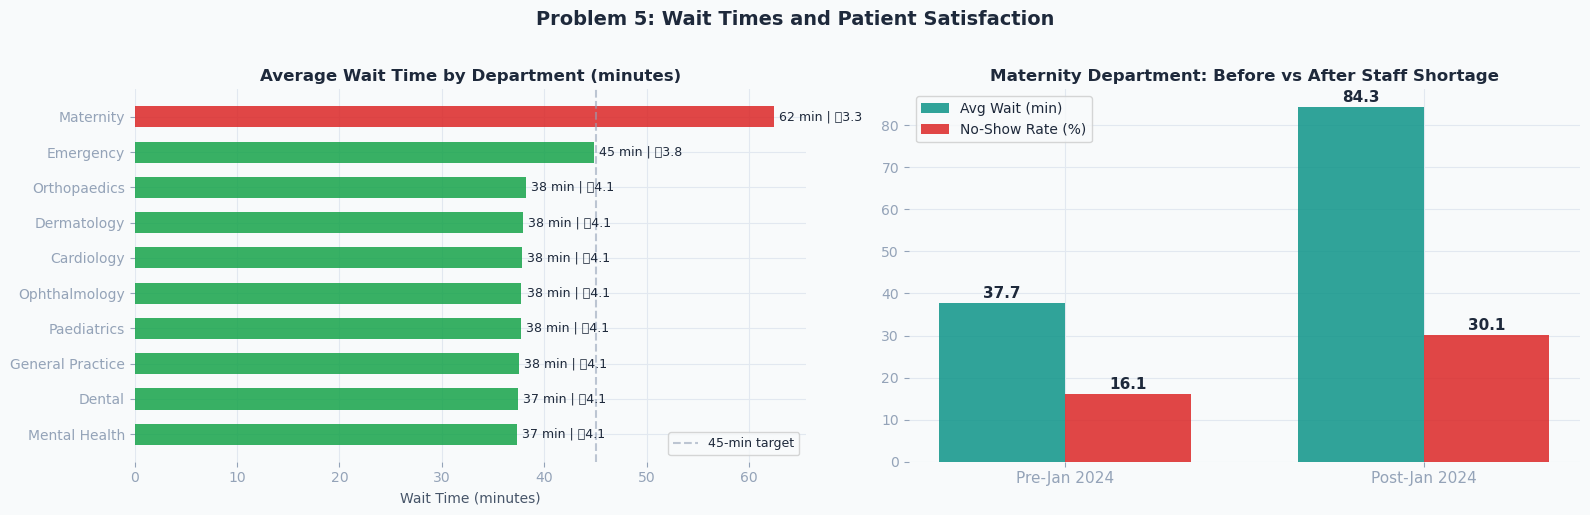

Saved p5_satisfaction.png


In [23]:
fig, axes = plt.subplots(1,2,figsize=(16,5))
fig.suptitle('Problem 5: Wait Times and Patient Satisfaction',fontsize=14,fontweight='bold',y=1.02)

wait_sorted = wait_sat.sort_values('avg_wait',ascending=True)
wc = [RED if w>60 else AMBER if w>45 else GREEN for w in wait_sorted['avg_wait']]
axes[0].barh(wait_sorted['department'], wait_sorted['avg_wait'],
             color=wc, alpha=0.85, height=0.6, zorder=2)
axes[0].set_title('Average Wait Time by Department (minutes)',fontsize=12,fontweight='bold')
axes[0].set_xlabel('Wait Time (minutes)')
axes[0].axvline(x=45,color=GRAY,linestyle='--',alpha=0.6,label='45-min target')
axes[0].legend(fontsize=9)
for i,(w,s) in enumerate(zip(wait_sorted['avg_wait'],wait_sorted['avg_sat'])):
    axes[0].text(w+0.5,i,f'{w:.0f} min | ⭐{s:.1f}',va='center',fontsize=9)

# Maternity before/after
periods=['Pre-Jan 2024','Post-Jan 2024']
waits=[37.7,84.3]; nosho=[16.1,30.1]
x=np.arange(len(periods)); width=0.35
axes[1].bar(x-width/2, waits, width, label='Avg Wait (min)',color=TEAL,alpha=0.85,zorder=2)
axes[1].bar(x+width/2, nosho,width, label='No-Show Rate (%)',color=RED,alpha=0.85,zorder=2)
axes[1].set_title('Maternity Department: Before vs After Staff Shortage',fontsize=12,fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(periods,fontsize=11)
axes[1].legend(fontsize=10)
for rect in axes[1].patches:
    h=rect.get_height()
    axes[1].text(rect.get_x()+rect.get_width()/2., h+0.5,
                 f'{h:.1f}',ha='center',va='bottom',fontsize=11,fontweight='bold')

plt.tight_layout()
plt.savefig('p5_satisfaction.png',dpi=150,bbox_inches='tight',facecolor='#f8fafb')
plt.show()
print("Saved p5_satisfaction.png")

---
## Executive Summary and Recommendations

In [24]:
print("=" * 65)
print("  MEDITRACK NIGERIA — EXECUTIVE SUMMARY")
print("=" * 65)
print()
print("PROBLEM 1: Revenue Fluctuation")
print("-" * 40)
hmo_bills_post = bills[(bills['payment_type']=='HMO/Insurance') & (bills['bill_date']>=pd.Timestamp('2024-01-01'))]
shortfall = (0.72 - 0.55) * hmo_bills_post['gross_amount'].mean() * len(hmo_bills_post)
print(f"  HMO coverage cut from 72% to 55% from Jan 2024")
print(f"  Estimated revenue shortfall from HMO cut: ₦{shortfall:,.0f}")
print(f"  Action: Renegotiate HMO contracts. Target 65%+ coverage.")
print()
print("PROBLEM 2: No-Show Crisis")
print("-" * 40)
print(f"  Mental Health no-show rate: 44.7% — needs appointment reminders")
print(f"  Dental no-show rate: 43.4% — needs deposit system")
mat_ns_rev = 2505 * 28610
print(f"  Maternity no-shows (post-Jan 2024) cost ≈ ₦{mat_ns_rev:,.0f}")
print(f"  Action: WhatsApp reminders 48h and 2h before appointments")
print()
print("PROBLEM 3: Patient Dropout")
print("-" * 40)
high_risk = patients[patients['dropout_risk_score']>75]
print(f"  {len(high_risk):,} patients ({len(high_risk)/len(patients)*100:.1f}%) have critical dropout risk")
oop_dropout = patients[patients['payment_type']=='Out-of-Pocket']['is_active'].mean()
print(f"  Out-of-Pocket patients active rate: {oop_dropout*100:.1f}%")
print(f"  Action: Payment plan options for Out-of-Pocket patients")
print()
print("PROBLEM 4: Channel Quality")
print("-" * 40)
print(f"  Doctor Referral patients: 32.3% still active — best channel")
print(f"  Social Media patients: 22.3% still active — worst quality")
print(f"  Action: Invest in GP partnership programme for more referrals")
print()
print("PROBLEM 5: Wait Times")
print("-" * 40)
print(f"  Maternity wait time doubled: 37.7 → 84.3 minutes")
print(f"  Patient satisfaction crashed: 4.1 → 2.7 out of 5")
print(f"  Action: Hire 2 additional Maternity staff immediately")
print()
print("=" * 65)
print(f"  Total revenue: ₦{bills['total_collected'].sum():,.0f}")
print(f"  Patients analysed: {len(patients):,}")
print("=" * 65)

  MEDITRACK NIGERIA — EXECUTIVE SUMMARY

PROBLEM 1: Revenue Fluctuation
----------------------------------------
  HMO coverage cut from 72% to 55% from Jan 2024
  Estimated revenue shortfall from HMO cut: ₦31,788,436
  Action: Renegotiate HMO contracts. Target 65%+ coverage.

PROBLEM 2: No-Show Crisis
----------------------------------------
  Mental Health no-show rate: 44.7% — needs appointment reminders
  Dental no-show rate: 43.4% — needs deposit system
  Maternity no-shows (post-Jan 2024) cost ≈ ₦71,668,050
  Action: WhatsApp reminders 48h and 2h before appointments

PROBLEM 3: Patient Dropout
----------------------------------------
  17,892 patients (71.6%) have critical dropout risk
  Out-of-Pocket patients active rate: 22.7%
  Action: Payment plan options for Out-of-Pocket patients

PROBLEM 4: Channel Quality
----------------------------------------
  Doctor Referral patients: 32.3% still active — best channel
  Social Media patients: 22.3% still active — worst quality
  Acti

---
*Analysis by MediTrack Nigeria Analytics Team | Python, pandas, matplotlib*